# Multilingual Language Detection & Translation System

## Project Overview:
This project is built from scratch using NLP and ML by using:
- Character-level N-gram feature extraction.
- TF-IDF Vectorization for feature weighting.
- Multinomial Naive Bayes classification across 17 languages.
- Google Translate API integration for translation in desired language.

In [5]:
# Installing dependencies
!pip install deep-translator langcodes[data]

In [6]:
# Importing dependencies

# Necessary for Step 1:
import pandas as pd

# Necessary for Step 2:
from sklearn.model_selection import train_test_split
import re

# Necessary for Step 3:
from sklearn.feature_extraction.text import TfidfVectorizer

# Necessary for Step 4:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Necessary for Step 5:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Necessary for Step 6:
import langcodes

# Necessary for Step 7:
from deep_translator import GoogleTranslator

## Step 1: Load and explore the dataset

In [7]:
df = pd.read_csv("language_data.csv")

In [8]:
df.shape

(10337, 2)

In [9]:
df.describe()

,Text,Language
count,10337,10337
unique,10267,17
top,mijn excuses.,English
freq,3,1385


In [10]:
df.head()

,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English


In [11]:
df['Language'].value_counts()

,count
Language,
English,1385
French,1014
Spanish,819
Portugeese,739
Italian,698
Russian,692
Sweedish,676
Malayalam,594
Dutch,546


## Step 2: Preprocessing the Text

In [12]:
# Making clean text

def clean_text(text):
  #obtain the text in lowercase
  text = text.lower()
  # Keep letters and spaces but remove special characters and numbers
  text = re.sub(r'[0-9@#$%^&*()_+=\[\]{};\'\\:"|<,./<>?]', ' ', text)
  # Remove extra spaces
  text = " ".join(text.split())
  return text

# Apply cleaning
df['cleaned_text'] = df['Text'].apply(clean_text)

print ("Before cleaning:")
print (df['Text'][10])
print ("\nAfter cleaning:")
print (df['cleaned_text'][10])

Before cleaning:
[1] Within the various uses of the word today, "nature" often refers to geology and wildlife.

After cleaning:
within the various uses of the word today nature often refers to geology and wildlife


In [13]:
# Splitting into text and language label
X = df['cleaned_text'] #input
Y = df['Language'] #output

# Train test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print (f"Training X samples: {len(X_train)}")
print (f"Testing X samples: {len(X_test)}")
print(f"Total samples: {len(X)}")
print(f"Training %: {len(X_train)/len(X)*100:.1f}%")
print(f"Testing %: {len(X_test)/len(X)*100:.1f}%")

Training X samples: 8269
Testing X samples: 2068
Total samples: 10337
Training %: 80.0%
Testing %: 20.0%


## Step 3: Character N-grams + TF-IDF Feature Extraction

In [14]:
# Creating TFIDF Vectorizer with n-grams character
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4), max_features=50000, sublinear_tf=True)

# Making it fit on training data, and transforming both
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Training vec shape:", X_train_vec.shape)
print("Testing vec shape:", X_test_vec.shape)
print(f"\nEach text is now represented as a vector of {X_train_vec.shape[1]} features")

Training vec shape: (8269, 50000)
Testing vec shape: (2068, 50000)

Each text is now represented as a vector of 50000 features


## Step 4: Training the Naive Bayes Model

In [15]:
# Training the model
model = MultinomialNB(alpha=0.1)
model.fit(X_train_vec, Y_train)

# Predicting on test data
Y_pred = model.predict(X_test_vec)

In [16]:
# Check accuracy
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Model Accuracy Score: {accuracy*100:.2f}%")

Model Accuracy Score: 99.18%


## Step 5: Model Evaluation with Confusion Matrix and Classification Report

In [17]:
# Obtaining Classification Report
print ("Classification Report:")
print (classification_report(Y_test, Y_pred))

Classification Report:
              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       107
      Danish       1.00      0.97      0.98        86
       Dutch       0.99      0.98      0.99       109
     English       0.97      1.00      0.98       277
      French       0.99      0.99      0.99       203
      German       1.00      0.99      0.99        94
       Greek       1.00      1.00      1.00        73
       Hindi       1.00      1.00      1.00        12
     Italian       0.99      1.00      1.00       140
     Kannada       1.00      1.00      1.00        74
   Malayalam       1.00      1.00      1.00       119
  Portugeese       0.99      0.99      0.99       148
     Russian       1.00      0.99      0.99       138
     Spanish       0.99      0.99      0.99       164
    Sweedish       0.99      0.99      0.99       135
       Tamil       1.00      1.00      1.00        94
     Turkish       1.00      0.99      0.99        95

   

In [18]:
# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred, labels=model.classes_)

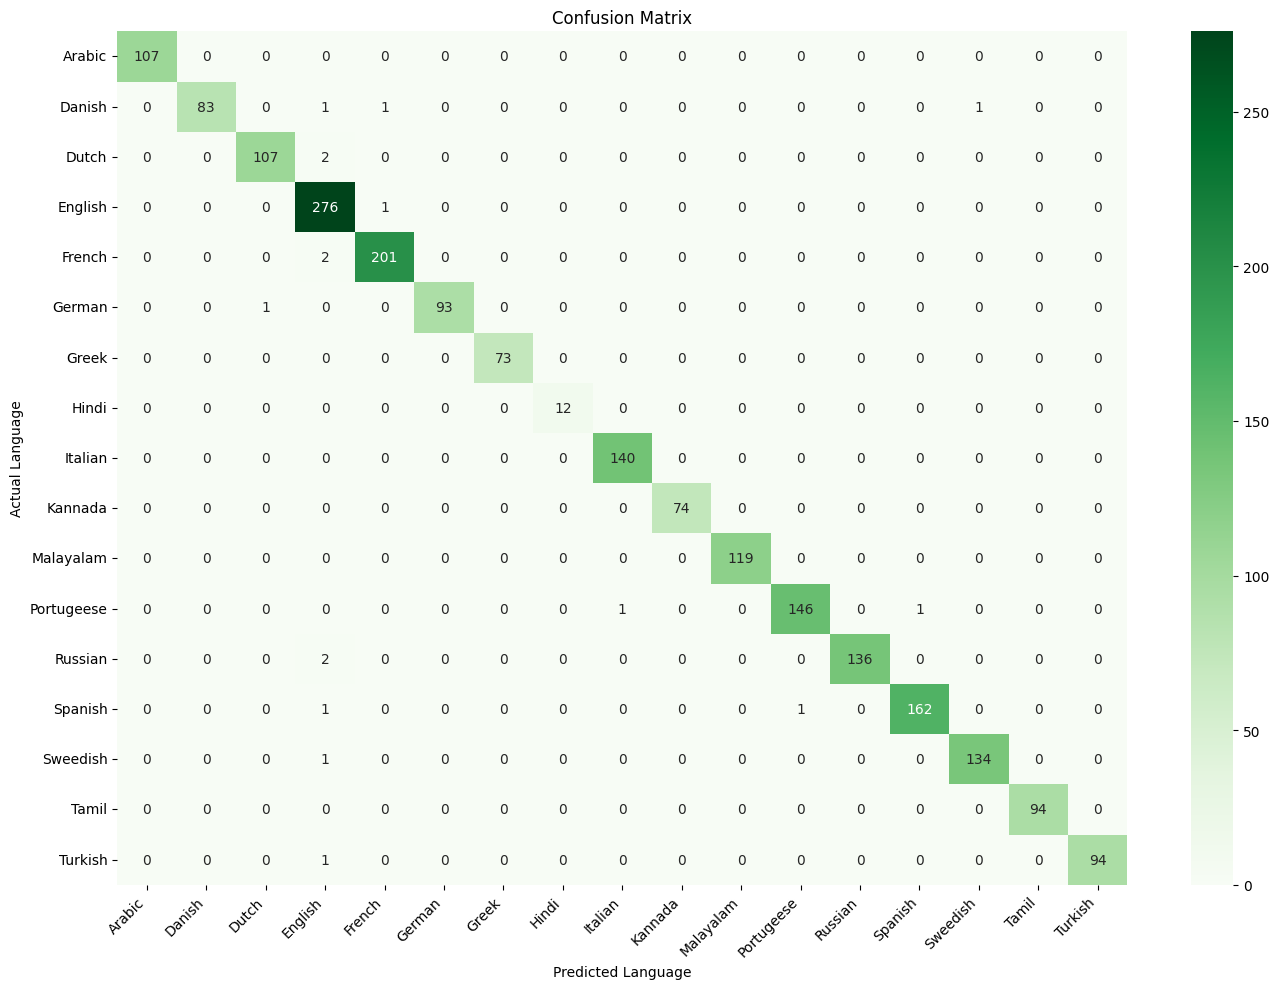

In [19]:
plt.figure(figsize=(14,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted Language")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Actual Language")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Observation: The model's misclassifications are linguistically meaningful as it occasionally confuses French with English and Dutch with English because they are historically related Germanic and Romance languages sharing similar character level patterns. Languages with unique scripts like Arabic, Greek and Hindi were classified with 100% accuracy.

## Step 6: Custom Prediction

In [20]:
# Cleaning the custom text
# Clean -> Vectorize -> Predict -> Confidence score

def predict_language(custom_text):
  cleaned_custom = clean_text(custom_text)
  vectorized_custom = vectorizer.transform([cleaned_custom])
  predicted_custom = model.predict(vectorized_custom)[0]
  probabilities_custom = model.predict_proba(vectorized_custom)[0]
  confidence_custom = max(probabilities_custom)*100

  print(f"Input Text: {custom_text}")
  print(f"Detected Language: {predicted_custom}")
  print(f"Confidence: {confidence_custom:.2f}%")
  print("*"*45)

predict_language("नमस्ते, आप कैसे हैं?")
predict_language("Hola, ¿cómo estás?")
predict_language("Bonjour, comment ça va?")
predict_language("你好吗?")
predict_language("Hello, how are you?")
predict_language("Ciao, come stai?")
predict_language("Guten Morgen, wie geht es dir?")
predict_language("I love Paris, c'est magnifique!")
predict_language("Permettez-moi de vous présenter")
predict_language("Hola")

Input Text: नमस्ते, आप कैसे हैं?
Detected Language: Hindi
Confidence: 100.00%
*********************************************
Input Text: Hola, ¿cómo estás?
Detected Language: Spanish
Confidence: 100.00%
*********************************************
Input Text: Bonjour, comment ça va?
Detected Language: French
Confidence: 99.98%
*********************************************
Input Text: 你好吗?
Detected Language: English
Confidence: 13.40%
*********************************************
Input Text: Hello, how are you?
Detected Language: English
Confidence: 99.99%
*********************************************
Input Text: Ciao, come stai?
Detected Language: Italian
Confidence: 97.60%
*********************************************
Input Text: Guten Morgen, wie geht es dir?
Detected Language: German
Confidence: 100.00%
*********************************************
Input Text: I love Paris, c'est magnifique!
Detected Language: French
Confidence: 97.96%
*********************************************
I

Observations:
1. When given Chinese text, our model predicted English with only 13.4% confidence, correctly signaling uncertainty. This highlights a key limitation, the model only detects the 17 languages present in training data.
2. Mixed English and French text was detected as French because "c'est magnigique" has very strong French n-gram patterns that outweigh the English part.
3. Hola only had 70.15% because the number of n-grams were few to analyze.

## Step 7: Translation pipeline

In [25]:
# Translating the custom text

translated_language = "english"

# Input text -> Clean -> vectorize -> detect language -> translate(if needed)
def detect_and_translate(new_text, target_language=translated_language):
  print(f"Input Text: {new_text}")

  # Clean and vectorize
  cleaned_new = clean_text(new_text)
  vectorize_new = vectorizer.transform([cleaned_new])

  # Detect language
  predicted_new = model.predict(vectorize_new)[0]
  probabilities_new = model.predict_proba(vectorize_new)[0]
  confidence_new = max(probabilities_new)*100

  print(f"Detected Language: {predicted_new}")
  print(f"Confidence: {confidence_new:.2f}%")

  # Warning for low confidence
  if confidence_new < 50:
    print(f"Warning: Low Confidence detected. \nHence, translation may not be accurate.")

  # Skip Translation if already in desired language
  if predicted_new.lower() == target_language.lower():
    print(f"The input text is already in {target_language}!")
    print("="*50)
    return

  # Translation
  try:
    translated_new = GoogleTranslator(source='auto', target=target_language).translate(new_text)
    print(f"Translated text: {translated_new}")
  except Exception as e:
    print(f"Translation Error: {e}")

  print("*"*50)

# To test
detect_and_translate("नमस्ते, आप कैसे हैं?")
detect_and_translate("Bonjour, comment ça va?")
detect_and_translate("Hola, ¿cómo estás?")
detect_and_translate("Guten Morgen, wie geht es dir?")
detect_and_translate("Hello, how are you?")


Input Text: नमस्ते, आप कैसे हैं?
Detected Language: Hindi
Confidence: 100.00%
Translated text: hello how are you?
**************************************************
Input Text: Bonjour, comment ça va?
Detected Language: French
Confidence: 99.98%
Translated text: Hello, how are you?
**************************************************
Input Text: Hola, ¿cómo estás?
Detected Language: Spanish
Confidence: 100.00%
Translated text: Hello how are you?
**************************************************
Input Text: Guten Morgen, wie geht es dir?
Detected Language: German
Confidence: 100.00%
Translated text: Good morning how are you?
**************************************************
Input Text: Hello, how are you?
Detected Language: English
Confidence: 99.99%
The input text is already in english!


Limitations observed:
1. Only detects 17 languages present in the training data.
2. Low confidence on very short texts due to fewer n-gram features.
3. Struggles with mixed language (code-switching) text.
4. Cannot handle languages with unseen scripts (Chinese).
5. For mixed-language texts, model is unable to handle it accurately.
6. Translation quality and formatting depends on the underlying Google Translate neural model. Our system correctly identifies the language with 100% confidence the translation output is handled by an external API whose behaviour varies by language pair. Hence, comma appears in French but not in other languages.